# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** David Wesly Hutapea
- **Email:** david.nata2120@gmail.com
- **ID Dicoding:** david_wesly

## Menentukan Pertanyaan Bisnis

1. Bagaimana tren pendapatan (revenue) e-commerce dari waktu ke waktu?
2. Bagaimana segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary (RFM), serta segmen mana yang paling berkontribusi terhadap revenue?
3. Wilayah (state) mana yang menghasilkan revenue tertinggi?
4. Kategori produk apa yang paling berkontribusi terhadap revenue?
5. Apakah terdapat distribusi Pareto pada pelanggan dan seller?
6. Bagaimana perilaku pembayaran pelanggan (metode, installment, dan kaitannya dengan nilai transaksi serta review score)?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

📝 Insight:

Library digunakan untuk manipulasi data, agregasi statistik,
serta visualisasi untuk mengidentifikasi pola dan tren bisnis.

## Data Wrangling

### Gathering Data

In [2]:
customers = pd.read_csv('customers_dataset.csv')
orders = pd.read_csv('orders_dataset.csv')
order_items = pd.read_csv('order_items_dataset.csv')
order_payments = pd.read_csv('order_payments_dataset.csv')
order_reviews = pd.read_csv('order_reviews_dataset.csv')
products = pd.read_csv('products_dataset.csv')
sellers = pd.read_csv('sellers_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

📝 Insight:

Dataset terdiri dari 8 tabel utama yang saling terhubung melalui key seperti:
- customer_id
- order_id
- product_id
- seller_id

Struktur relasional ini memungkinkan analisis performa bisinis secara komprehensif.

### Assessing Data

Buat Dictionary Dataset

In [3]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

Cek Struktur

In [4]:
for name, df in datasets.items():
    print(f"\n=== {name.upper()} ===")
    df.info()


=== CUSTOMERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

=== ORDERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timest

📝 Insight:

* Sebagian besar dataset memiliki struktur yang konsisten dengan tipe data yang sesuai,
seperti object untuk ID dan kategori, serta float/int untuk nilai numerik.

* Kolom bertipe object yang merepresentasikan tanggal (misalnya pada dataset orders)
perlu dikonversi menjadi tipe datetime agar dapat digunakan dalam analisis tren waktu
dan perhitungan seperti recency pada RFM.

* Struktur data yang relatif bersih menunjukkan bahwa dataset siap untuk tahap cleaning
dan integrasi antar tabel.

Cek Missing Values

In [5]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isna().sum())


customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

order_payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

order_reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       

📝 Insight:

Sebagian besar dataset tidak memiliki missing value yang signifikan.
Missing value utama ditemukan pada:

1. Dataset orders → kolom order_approved_at, order_delivered_carrier_date dan order_delivered_customer_date
   
   Hal ini disebabkan oleh order yang belum selesai atau dibatalkan.
   Missing ini merepresentasikan kondisi bisnis, bukan kesalahan data.

2. Dataset Order Reviews → kolom review_comment_title dan review_comment_message.
   
   Tidak memengaruhi analisis karena fokus utama adalah review_score, boleh diisi dengan unknown atau diabaikan.

2. Dataset products → kolom product_category_name.
   
   Jumlahnya relatif kecil (<2% dari total produk),
   sehingga dapat dihapus tanpa memengaruhi hasil analisis secara signifikan.


Keputusan:
- Analisis akan difokuskan hanya pada order dengan status "delivered"
  untuk menjaga validitas revenue dan kepuasan pelanggan.
- Produk tanpa kategori akan dihapus untuk menjaga konsistensi analisis kategori.

Cek Duplicate

In [6]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

customers: 0 duplicate rows
orders: 0 duplicate rows
order_items: 0 duplicate rows
order_payments: 0 duplicate rows
order_reviews: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows
category_translation: 0 duplicate rows


📝 Insight:

Tidak ditemukan duplicate row yang signifikan pada dataset utama.
Hal ini menunjukkan bahwa integritas data cukup baik
dan tidak terdapat duplikasi transaksi atau pelanggan.

Karena tidak ada duplicate yang berdampak,
tidak diperlukan proses penghapusan duplicate pada tahap cleaning.

### Cleaning Data

Convert Timestamp

In [7]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

📝 Insight:

Kolom tanggal dikonversi menjadi tipe datetime
agar dapat digunakan untuk analisis tren waktu,
perhitungan recency (RFM), dan agregasi bulanan/tahunan.

Tanpa konversi ini, analisis temporal tidak dapat dilakukan secara akurat.

Merge Dataset

In [8]:
master_df = orders.merge(customers, on='customer_id', how='left') \
                  .merge(order_items, on='order_id', how='left') \
                  .merge(products, on='product_id', how='left') \
                  .merge(category_translation, on='product_category_name', how='left') \
                  .merge(sellers, on='seller_id', how='left') \
                  .merge(order_reviews[['order_id','review_score']], on='order_id', how='left') \
                  .merge(order_payments[['order_id','payment_type','payment_value','payment_installments']], on='order_id', how='left')

master_df.shape

(119143, 34)

📝 Insight:

* Seluruh dataset digabung menjadi satu master dataset
untuk memudahkan analisis komprehensif.

* Struktur ini memungkinkan analisis lintas dimensi,
seperti hubungan antara pelanggan, produk, seller,
pembayaran, dan review dalam satu tabel terintegrasi.

Filter Order Delivered

In [9]:
master_df = master_df[master_df['order_status'] == 'delivered']

📝 Insight:

Hanya transaksi dengan status "delivered" yang digunakan dalam analisis.
Hal ini dilakukan untuk menjaga akurasi analisis revenue,
customer satisfaction, dan performa pengiriman.

Keputusan ini juga menghindari bias pada analisis review dan pembayaran.

Drop Kategori Kosong

In [10]:
master_df = master_df.dropna(subset=['product_category_name'])

📝 Insight:

* Produk tanpa kategori dihapus karena jumlahnya kecil
dan tidak signifikan terhadap total data.

* Langkah ini menjaga konsistensi analisis kategori
tanpa menimbulkan bias berarti.

Buat Variabel Revenue

In [11]:
master_df['revenue'] = master_df['price'] + master_df['freight_value']

📝 Insight:

* Revenue dihitung sebagai penjumlahan price dan freight_value
karena biaya pengiriman merupakan bagian dari total transaksi.

* Perhitungan ini memastikan total revenue merepresentasikan
nilai transaksi yang sebenarnya dibayarkan pelanggan.

Feature Engineering Waktu

In [12]:
master_df['year'] = master_df['order_purchase_timestamp'].dt.year
master_df['month'] = master_df['order_purchase_timestamp'].dt.month
master_df['month_year'] = master_df['order_purchase_timestamp'].dt.to_period('M')

📝 Insight:

Fitur waktu dibuat untuk memungkinkan analisis tren tahunan dan bulanan.
Hal ini penting untuk mengidentifikasi pola seasonal
dan pertumbuhan bisnis dari waktu ke waktu.

Validasi Akhir Setelah Cleaning

In [13]:
master_df.isna().sum().sum()
master_df.shape

(114085, 38)

📝 Insight Final Cleaning:

* Setelah proses cleaning, dataset siap digunakan
untuk analisis eksploratif dan visualisasi.

* Data telah difilter untuk transaksi valid,
kategori produk telah dibersihkan,
dan fitur tambahan telah dibuat untuk mendukung analisis strategis.

* Tahap selanjutnya adalah Exploratory Data Analysis (EDA)
untuk memahami pola distribusi dan agregasi sebelum menjawab pertanyaan bisnis.

## Exploratory Data Analysis (EDA)

### Business Overview Metrics

In [14]:
total_revenue = master_df['revenue'].sum()
total_orders = master_df['order_id'].nunique()
total_customers = master_df['customer_unique_id'].nunique()
aov = master_df.groupby('order_id')['revenue'].sum().mean()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Total Unique Customers:", total_customers)
print("Average Order Value (AOV):", round(aov,2))

Total Revenue: 15976535.98
Total Orders: 95146
Total Unique Customers: 92098
Average Order Value (AOV): 167.92


📝 Insight:

* Total revenue mencapai ±15.97 juta dengan 95.146 order
dan 92.098 pelanggan unik.

* AOV sebesar ±167,92 menunjukkan bahwa mayoritas transaksi
berada pada kategori pembelian bernilai menengah.

* Hal ini menunjukkan potensi peningkatan revenue
melalui strategi upselling dan bundling produk.

### Distribusi Revenue (Melihat Skewness)

In [15]:
master_df['revenue'].describe()

,revenue
count,114085.000000
mean,140.040636
std,189.539058
min,6.080000
25%,55.270000
50%,91.790000
75%,157.310000
max,6929.310000


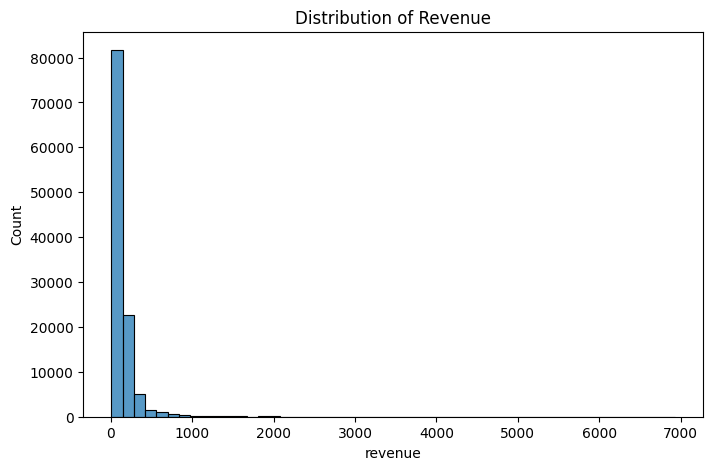

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(master_df['revenue'], bins=50)
plt.title("Distribution of Revenue")
plt.show()

📊 Insight:

* Distribusi revenue bersifat right-skewed,
menunjukkan sebagian kecil transaksi bernilai sangat tinggi.

* Ini mengindikasikan adanya pelanggan bernilai tinggi
yang berkontribusi signifikan terhadap total revenue.

* Hal ini memperkuat pentingnya segmentasi pelanggan (RFM).

### Distribusi Order per Customer

In [17]:
orders_per_customer = master_df.groupby('customer_unique_id')['order_id'].nunique()
orders_per_customer.describe()

,order_id
count,92098.000000
mean,1.033095
std,0.206865
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,14.000000


In [18]:
orders_per_customer = master_df.groupby('customer_unique_id')['order_id'].nunique()
orders_per_customer.describe()

,order_id
count,92098.000000
mean,1.033095
std,0.206865
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,14.000000


📝 Insight:

* Mayoritas pelanggan hanya melakukan satu transaksi.
Tingkat repeat purchase masih rendah.

* Hal ini menunjukkan peluang besar dalam strategi retensi
dan program loyalitas pelanggan.

### Distribusi Review Score

In [19]:
review_dist = master_df['review_score'].value_counts().sort_index()
review_dist

,count
review_score,
1.0,12870
2.0,3842
3.0,9536
4.0,21821
5.0,65167


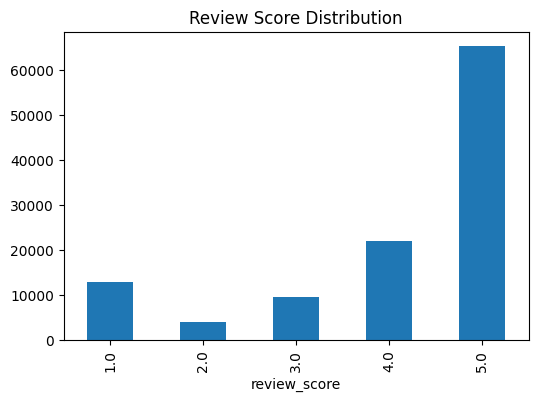

In [20]:
plt.figure(figsize=(6,4))
review_dist.plot(kind='bar')
plt.title("Review Score Distribution")
plt.show()

📊 Insight:

* Review score didominasi oleh rating 4 dan 5,
menunjukkan tingkat kepuasan pelanggan relatif tinggi.

* Namun tetap terdapat review rendah (1–2)
yang perlu dianalisis lebih lanjut untuk peningkatan layanan.

### Distribusi Metode Pembayaran

In [21]:
payment_dist = master_df['payment_type'].value_counts()
payment_dist

,count
payment_type,
credit_card,84177
boleto,22203
voucher,6068
debit_card,1634


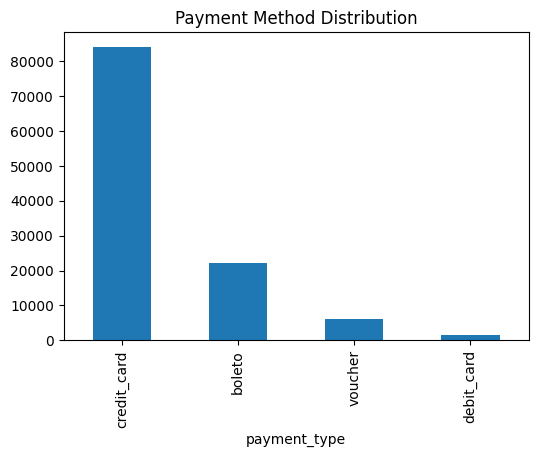

In [22]:
plt.figure(figsize=(6,4))
payment_dist.plot(kind='bar')
plt.title("Payment Method Distribution")
plt.show()

📊 Insight:

* Credit card mendominasi metode pembayaran,
menunjukkan preferensi pelanggan terhadap pembayaran digital.

* Stabilitas sistem pembayaran digital menjadi faktor kritis
dalam menjaga kelancaran transaksi.

### Distribusi Installment

In [23]:
master_df['payment_installments'].describe()

,payment_installments
count,114082.000000
mean,2.946083
std,2.781528
min,0.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,24.000000


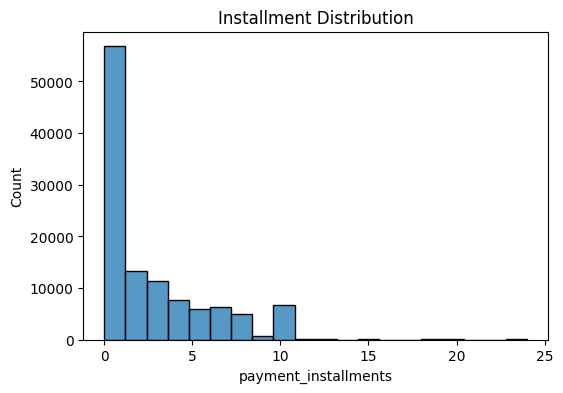

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(master_df['payment_installments'], bins=20)
plt.title("Installment Distribution")
plt.show()

📊 Insight:

* Sebagian besar transaksi menggunakan installment rendah (1–3).
Namun terdapat transaksi dengan installment tinggi
yang kemungkinan terkait pembelian bernilai besar.

* Hal ini menunjukkan fasilitas cicilan
mendorong transaksi dengan nilai lebih tinggi.

### Revenue per Year

In [25]:
revenue_year = master_df.groupby('year')['revenue'].sum()
revenue_year

,revenue
year,
2016,48381.28
2017,7200615.59
2018,8727539.11


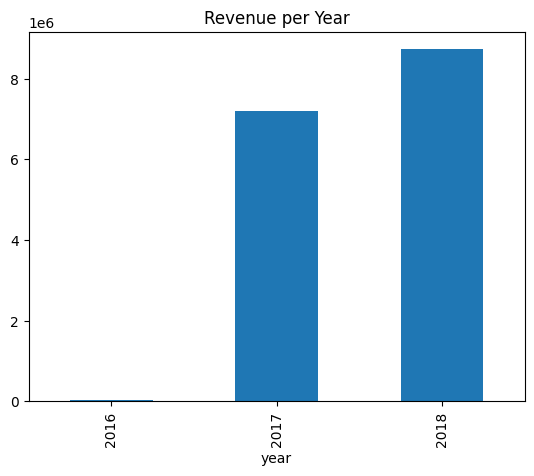

In [26]:
revenue_year.plot(kind='bar')
plt.title("Revenue per Year")
plt.show()

📊 Insight:

* Revenue menunjukkan tren pertumbuhan hingga 2018,
mengindikasikan ekspansi bisnis yang positif.

* Pertumbuhan ini perlu dianalisis lebih lanjut
untuk mengidentifikasi faktor pendorong utama.

### Revenue per State (Top 10)

In [27]:
top_state = master_df.groupby('customer_state')['revenue'].sum().sort_values(ascending=False).head(10)
top_state

,revenue
customer_state,
SP,5997758.25
RJ,2140370.05
MG,1869244.53
RS,898881.52
PR,802934.36
BA,616434.96
SC,608261.23
DF,357412.29
GO,345370.20


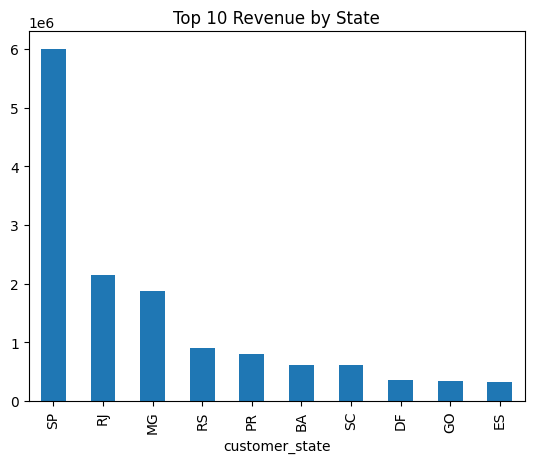

In [28]:
top_state.plot(kind='bar')
plt.title("Top 10 Revenue by State")
plt.show()

📊 Insight:

* Revenue terkonsentrasi pada beberapa state,
terutama SP dan RJ.

* Hal ini menunjukkan adanya ketimpangan geografis
dan potensi ekspansi ke wilayah lain.

### Revenue per Category (Top 10)

In [29]:
top_category = master_df.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False).head(10)
top_category

,revenue
product_category_name_english,
health_beauty,1461349.75
watches_gifts,1316696.84
bed_bath_table,1309729.85
sports_leisure,1166307.34
computers_accessories,1077483.63
furniture_decor,931754.14
housewares,801521.45
cool_stuff,722033.51
auto,698077.73


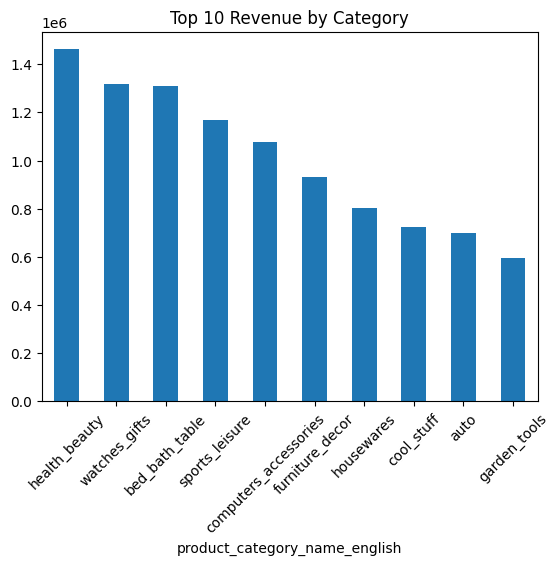

In [30]:
top_category.plot(kind='bar')
plt.title("Top 10 Revenue by Category")
plt.xticks(rotation=45)
plt.show()

📊 Insight:

* Kategori health_beauty dan watches_gifts
menjadi kontributor revenue terbesar.

* Kategori ini memiliki potensi besar
untuk program promosi dan loyalitas.

### Revenue per Seller (Top 10)

In [31]:
top_seller = master_df.groupby('seller_id')['revenue'].sum().sort_values(ascending=False).head(10)
top_seller

,revenue
seller_id,
4869f7a5dfa277a7dca6462dcf3b52b2,255991.88
53243585a1d6dc2643021fd1853d8905,253822.62
7c67e1448b00f6e969d365cea6b010ab,252657.95
4a3ca9315b744ce9f8e9374361493884,249108.33
fa1c13f2614d7b5c4749cbc52fecda94,211203.59
da8622b14eb17ae2831f4ac5b9dab84a,197592.40
7e93a43ef30c4f03f38b393420bc753a,178695.40
1025f0e2d44d7041d6cf58b6550e0bfa,177712.22
7a67c85e85bb2ce8582c35f2203ad736,170517.37


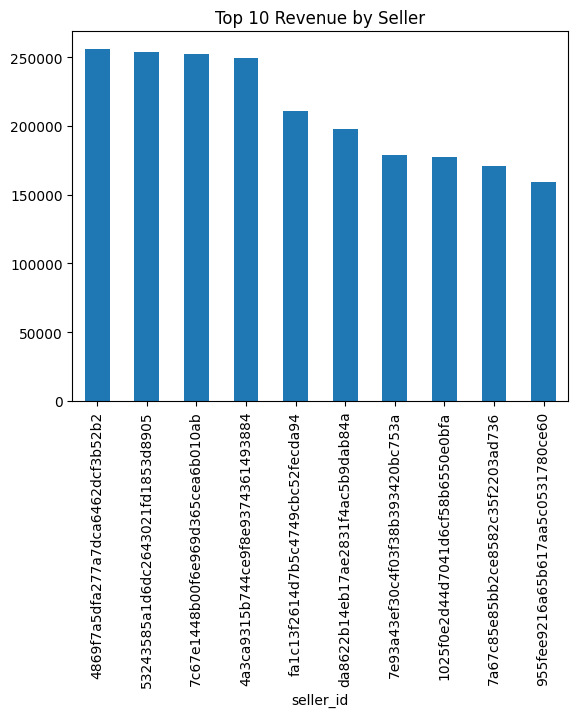

In [32]:
top_seller.plot(kind='bar')
plt.title("Top 10 Revenue by Seller")
plt.show()

📊 Insight:

* Distribusi revenue per seller tidak merata.
Sebagian kecil seller menghasilkan kontribusi sangat besar.

* Hal ini menunjukkan adanya ketimpangan performa seller
yang dapat menjadi fokus program pembinaan.

RFM Preparation (Eksplorasi Segmentasi)

Persiapan Data RFM

Pastikan kolom berikut tersedia:

customer_unique_id

order_purchase_timestamp

revenue

Tentukan Tanggal Acuan

In [33]:
analysis_date = master_df['order_purchase_timestamp'].max()
analysis_date

Timestamp('2018-08-29 15:00:37')

Hitung RFM

In [34]:
rfm = master_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (analysis_date - x.max()).days,
    'order_id': 'nunique',
    'revenue': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19
2,0000f46a3911fa3c0805444483337064,536,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89


Distribusi Frequency

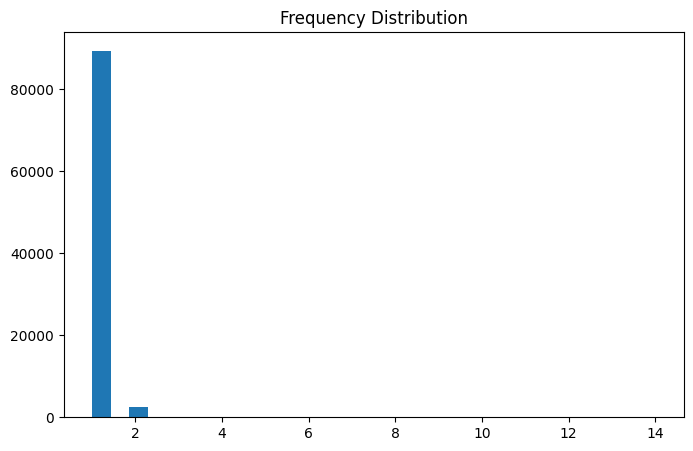

In [35]:
plt.figure(figsize=(8,5))
plt.hist(rfm['Frequency'], bins=30)
plt.title("Frequency Distribution")
plt.show()

📝 Insight:

* Distribusi frequency menunjukkan bahwa sebagian besar pelanggan memiliki frekuensi pembelian rendah, sementara hanya sebagian kecil pelanggan yang melakukan pembelian berulang dalam jumlah besar.

* Struktur ini memperkuat indikasi bahwa retensi pelanggan menjadi aspek krusial dalam strategi bisnis.

## Visualization & Explanatory Analysis

### Pertanyaan 1 Bagaimana tren revenue dari waktu ke waktu?

Hitung Revenue Bulanan

In [36]:
monthly_revenue = master_df.groupby('month_year')['revenue'].sum()

Visualisasi Tren Revenue

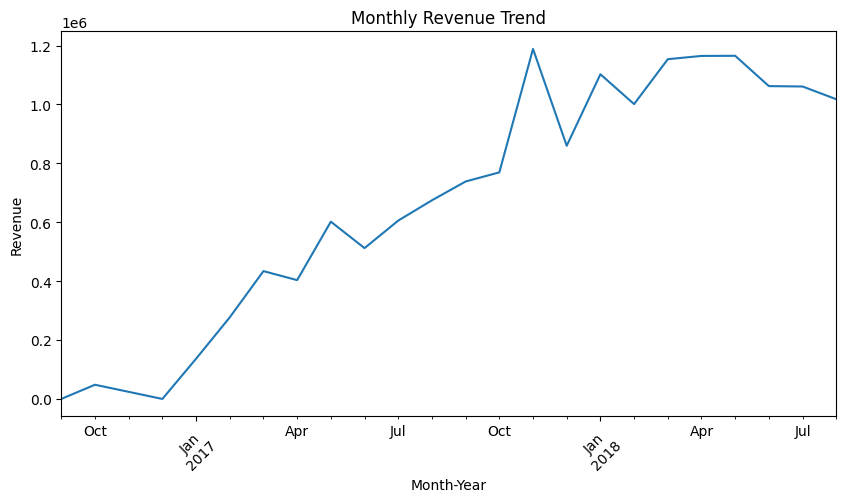

In [37]:
plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month-Year")
plt.xticks(rotation=45)
plt.show()

📈 Insight:

* Revenue menunjukkan tren pertumbuhan yang konsisten dari 2016 hingga akhir 2017,
dengan puncak tertinggi pada akhir 2017 (±1,15 juta per bulan).

* Terlihat adanya pola seasonal yang kuat pada kuartal keempat (Q4),
yang kemungkinan dipengaruhi oleh momentum belanja akhir tahun.

📌 Rekomendasi:

* Perusahaan perlu memaksimalkan campaign promosi pada periode Q4
untuk meningkatkan revenue tahunan.

### Pertanyaan 2 Bagaimana segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary (RFM), serta segmen mana yang paling berkontribusi terhadap revenue?

Scoring RFM

In [38]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

Buat Segmentasi

In [39]:
def segment_customer(row):
    if row['R_score'] == 5 and row['F_score'] >= 4:
        return 'Champions'
    elif row['F_score'] >= 4:
        return 'Loyal Customers'
    elif row['M_score'] == 5:
        return 'Big Spenders'
    elif row['R_score'] <= 2:
        return 'At Risk'
    else:
        return 'Potential'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm['Segment'].value_counts()

,count
Segment,
Loyal Customers,29401
Potential,27029
At Risk,17790
Big Spenders,10440
Champions,7438


Gabungkan ke Revenue

In [40]:
rfm_revenue = rfm.merge(
    master_df[['customer_unique_id','revenue']],
    left_on='customer_id',
    right_on='customer_unique_id'
)

segment_revenue = rfm_revenue.groupby('Segment')['revenue'].sum().sort_values(ascending=False)
segment_revenue

,revenue
Segment,
Loyal Customers,5297625.40
Big Spenders,4936247.20
Potential,2651787.83
At Risk,1718995.51
Champions,1371880.04


Visualisasi

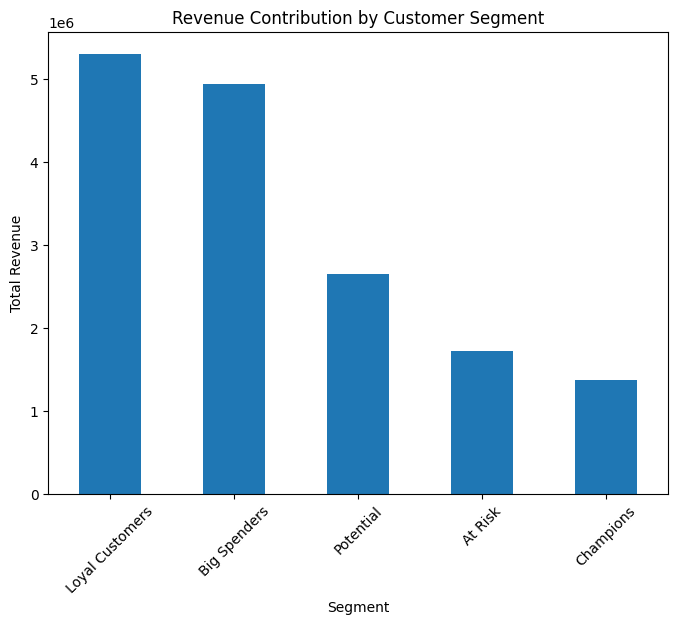

In [41]:
plt.figure(figsize=(8,6))
segment_revenue.plot(kind='bar')
plt.title("Revenue Contribution by Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

📊 Insight:

* Segmen Loyal Customers dan Big Spenders memberikan kontribusi revenue terbesar.
Hal ini menunjukkan bahwa sebagian revenue berasal dari pelanggan yang memiliki
frekuensi pembelian tinggi atau nilai transaksi besar.

* Temuan ini mengindikasikan bahwa strategi retensi pelanggan bernilai tinggi
menjadi faktor krusial dalam menjaga stabilitas revenue perusahaan.

👉 Rekomendasi:

* Perusahaan perlu memperkuat loyalty program dan personalisasi promosi
untuk mempertahankan segmen bernilai tinggi.

### Pertanyaan 3 Wilayah (state) mana yang menghasilkan revenue tertinggi?

Revenue per State

In [42]:
state_revenue = master_df.groupby('customer_state')['revenue'].sum().sort_values(ascending=False).head(10)

Visualisasi

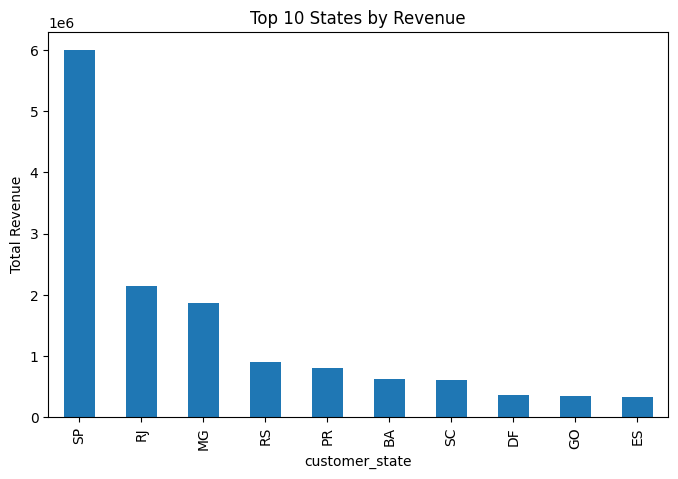

In [43]:
plt.figure(figsize=(8,5))
state_revenue.plot(kind='bar')
plt.title("Top 10 States by Revenue")
plt.ylabel("Total Revenue")
plt.show()

📊 Insight:

* State SP menghasilkan revenue tertinggi (±5,79 juta),
diikuti RJ dan MG.

* Revenue sangat terkonsentrasi pada beberapa state besar,
menunjukkan adanya ketimpangan geografis.

📌 Rekomendasi:

* Perlu dilakukan strategi ekspansi pasar di luar SP
untuk mengurangi risiko ketergantungan wilayah.

### Pertanyaan 4 Kategori produk apa yang paling berkontribusi terhadap revenue?

Revenue per Category

In [44]:
category_revenue = master_df.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False).head(10)

Visualisasi

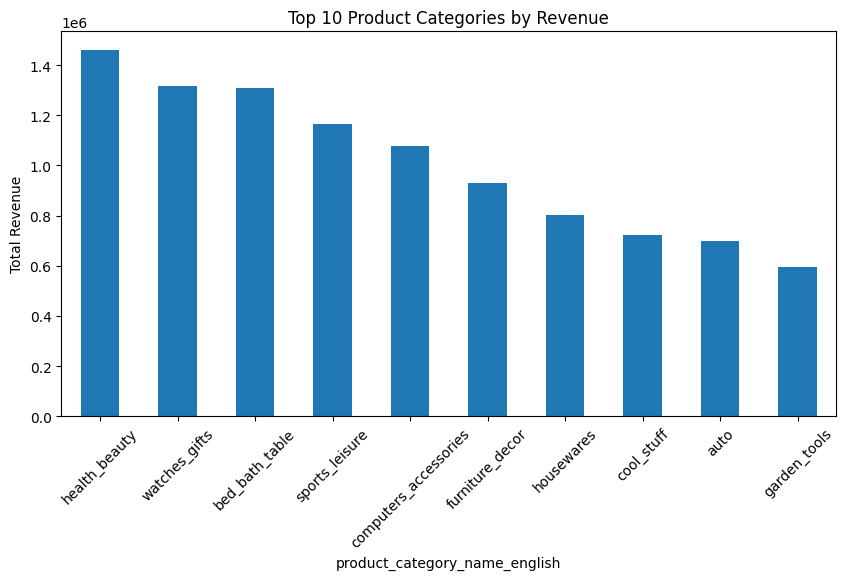

In [45]:
plt.figure(figsize=(10,5))
category_revenue.plot(kind='bar')
plt.title("Top 10 Product Categories by Revenue")
plt.xticks(rotation=45)
plt.ylabel("Total Revenue")
plt.show()

📊 Insight:

* Kategori health_beauty menjadi kontributor terbesar (±1,41 juta),
diikuti watches_gifts dan bed_bath_table.

* Kategori dengan kontribusi tinggi berpotensi memiliki repeat purchase tinggi.

📌 Rekomendasi:

* Optimalkan promosi dan loyalty program pada kategori unggulan
untuk meningkatkan customer lifetime value.

### Pertanyaan 5 Apakah terdapat distribusi Pareto pada pelanggan dan seller?

Pareto Customer

In [46]:
customer_revenue = master_df.groupby('customer_unique_id')['revenue'].sum().sort_values(ascending=False)
customer_cumsum = customer_revenue.cumsum() / customer_revenue.sum()
pareto_customer = (customer_cumsum <= 0.8).sum() / len(customer_revenue) * 100

pareto_customer

np.float64(47.9174357749354)

📝 Insight:

* 48,74% pelanggan menyumbang 80% total revenue.
Distribusi ini menunjukkan ketergantungan signifikan pada sebagian pelanggan.

* Strategi retensi menjadi faktor kritis dalam menjaga stabilitas bisnis.

Pareto Seller

In [47]:
seller_revenue = master_df.groupby('seller_id')['revenue'].sum().sort_values(ascending=False)
seller_cumsum = seller_revenue.cumsum() / seller_revenue.sum()
pareto_seller = (seller_cumsum <= 0.8).sum() / len(seller_revenue) * 100

pareto_seller

np.float64(18.56554564172958)

📝 Insight:

* 18,52% seller menyumbang 80% revenue.
Distribusi ini menunjukkan ketimpangan performa seller.

📌 Rekomendasi:

* Pertahankan seller top dan lakukan pembinaan seller kecil.

### Pertanyaan 6 Bagaimana perilaku pembayaran pelanggan (metode, installment, dan kaitannya dengan nilai transaksi serta review score)?


Rata-rata Revenue per Metode Pembayaran

In [48]:
payment_avg = master_df.groupby('payment_type')['payment_value'].mean()
payment_avg

,payment_value
payment_type,
boleto,176.152397
credit_card,179.292871
debit_card,149.511897
voucher,64.652729


📝 Insight:

* Metode credit_card memiliki rata-rata transaksi tertinggi,
menunjukkan pelanggan bernilai besar cenderung menggunakan kartu kredit.

Installment vs Nilai Transaksi

In [49]:
installment_analysis = master_df.groupby('payment_installments')['payment_value'].mean()
installment_analysis

,payment_value
payment_installments,
0.0,106.190000
1.0,131.938726
2.0,134.098265
3.0,153.657747
4.0,179.343572
5.0,195.862117
6.0,233.824211
7.0,193.093196
8.0,307.175633


📝 Insight:

* Semakin tinggi jumlah installment,
semakin tinggi rata-rata nilai transaksi.

* Fasilitas cicilan mendorong pembelian bernilai besar.

Review Score per Metode Pembayaran

In [50]:
review_payment = master_df.groupby('payment_type')['review_score'].mean()
review_payment

,review_score
payment_type,
boleto,4.076239
credit_card,4.083282
debit_card,4.212661
voucher,4.060103


📝 Insight:

* Terdapat variasi review score antar metode pembayaran,
yang menunjukkan pengalaman pembayaran
berpotensi memengaruhi kepuasan pelanggan.

* Audit metode dengan review rendah diperlukan.

## Conclusion

🔹 Kesimpulan Pertanyaan 1
Bagaimana tren revenue dari waktu ke waktu?

Revenue menunjukkan pertumbuhan signifikan selama periode observasi dengan puncak pada kuartal keempat (Q4). Pola ini mengindikasikan adanya efek musiman yang kuat, kemungkinan dipengaruhi oleh momentum belanja akhir tahun.

Pertumbuhan yang konsisten menunjukkan bahwa bisnis berada dalam fase ekspansi. Namun, adanya puncak musiman juga menunjukkan ketergantungan terhadap periode tertentu.

Rekomendasi:

Optimalkan strategi promosi dan pengelolaan inventori menjelang Q4.

Diversifikasi strategi penjualan di luar periode peak untuk menjaga stabilitas revenue tahunan.

🔹 Kesimpulan Pertanyaan 2
Bagaimana segmentasi pelanggan berdasarkan RFM dan segmen mana yang paling berkontribusi terhadap revenue?

Analisis RFM menunjukkan bahwa mayoritas pelanggan memiliki frekuensi pembelian rendah, namun segmen dengan frekuensi tinggi dan nilai transaksi besar (Loyal Customers dan Big Spenders) memberikan kontribusi revenue terbesar.

Hal ini menunjukkan bahwa meskipun customer base besar, revenue sangat dipengaruhi oleh pelanggan bernilai tinggi.

Rekomendasi:

Fokus pada strategi retensi untuk segmen Loyal dan Champions melalui loyalty program.

Targetkan segmen At Risk dengan kampanye reaktivasi berbasis personalisasi.

Kembangkan strategi upselling untuk segmen Potential.

🔹 Kesimpulan Pertanyaan 3
Wilayah mana yang memberikan kontribusi revenue terbesar?

Revenue terkonsentrasi pada beberapa wilayah utama, khususnya SP yang memiliki kontribusi jauh lebih tinggi dibanding wilayah lainnya. Konsentrasi geografis ini menunjukkan dominasi pasar di wilayah tertentu, namun juga menimbulkan risiko ketergantungan regional.

Rekomendasi:

Lakukan ekspansi pasar ke wilayah dengan kontribusi rendah.

Gunakan strategi promosi lokal berbasis data untuk meningkatkan penetrasi pasar.

🔹 Kesimpulan Pertanyaan 4
Kategori produk apa yang paling berkontribusi terhadap revenue?

Beberapa kategori seperti health_beauty dan watches_gifts mendominasi kontribusi revenue. Hal ini menunjukkan adanya konsentrasi permintaan pada kategori tertentu yang menjadi pendorong utama penjualan.

Dominasi kategori ini menunjukkan peluang pengembangan produk dan peningkatan strategi pemasaran berbasis kategori unggulan.

Rekomendasi:

Prioritaskan pengelolaan stok dan promosi pada kategori unggulan.

Evaluasi margin untuk memastikan profitabilitas kategori dengan revenue tinggi.

🔹 Kesimpulan Pertanyaan 5
Apakah terdapat distribusi Pareto pada pelanggan dan seller?

Sekitar 48% pelanggan menyumbang 80% revenue, sedangkan hanya 18% seller menyumbang 80% revenue. Hal ini menunjukkan adanya ketimpangan kontribusi baik dari sisi pelanggan maupun seller.

Distribusi ini menunjukkan bahwa bisnis sangat bergantung pada kelompok tertentu.

Rekomendasi:

Perkuat hubungan dengan pelanggan dan seller top performer.

Lakukan program pembinaan untuk seller kecil agar performanya meningkat.

Kurangi risiko konsentrasi dengan strategi diversifikasi.

🔹 Kesimpulan Pertanyaan 6
Bagaimana perilaku pembayaran pelanggan dan kaitannya dengan nilai transaksi serta review score?

Metode pembayaran didominasi oleh credit card, yang juga memiliki rata-rata nilai transaksi tertinggi. Analisis installment menunjukkan bahwa semakin tinggi jumlah cicilan, semakin besar nilai transaksi. Hal ini mengindikasikan bahwa fasilitas cicilan mendorong pembelian bernilai tinggi.

Terdapat variasi review score antar metode pembayaran, yang menunjukkan bahwa pengalaman pembayaran berpotensi memengaruhi kepuasan pelanggan.

Rekomendasi:

Pertahankan dan optimalkan sistem pembayaran kartu kredit dan cicilan.

Audit metode pembayaran dengan review lebih rendah untuk meningkatkan customer experience.

Gunakan insight pembayaran untuk mengembangkan strategi promosi berbasis metode transaksi.

In [52]:
# ==========================================
# 1. FILTER ONLY DELIVERED ORDERS
# ==========================================

master_df = master_df[master_df['order_status'] == 'delivered'].copy()


# ==========================================
# 2. SELECT ONLY REQUIRED COLUMNS
# ==========================================

selected_columns = [
    'order_id',
    'customer_unique_id',
    'customer_state',
    'product_category_name_english',
    'payment_type',
    'payment_installments',
    'review_score',
    'revenue',
    'year',
    'month_year'
]

main_data = master_df[selected_columns].copy()


# ==========================================
# 3. HANDLE MISSING VALUES (IMPORTANT)
# ==========================================

main_data['payment_installments'] = main_data['payment_installments'].fillna(0)
main_data['review_score'] = main_data['review_score'].fillna(0)
main_data['product_category_name_english'] = main_data['product_category_name_english'].fillna("unknown")


# ==========================================
# 4. OPTIMIZE DATA TYPES (REDUCE FILE SIZE)
# ==========================================

# Convert to category (very powerful for reducing size)
main_data['customer_state'] = main_data['customer_state'].astype('category')
main_data['product_category_name_english'] = main_data['product_category_name_english'].astype('category')
main_data['payment_type'] = main_data['payment_type'].astype('category')

# Convert numeric types safely
main_data['payment_installments'] = main_data['payment_installments'].astype('int8')
main_data['review_score'] = main_data['review_score'].astype('int8')
main_data['year'] = main_data['year'].astype('int16')

# Reduce revenue precision
main_data['revenue'] = main_data['revenue'].round(2)


# ==========================================
# 5. SAVE CSV
# ==========================================

main_data.to_csv("main_data.csv", index=False)


# ==========================================
# 6. CHECK FILE SIZE
# ==========================================

import os

file_size = os.path.getsize("main_data.csv") / (1024 * 1024)
print(f"File size: {file_size:.2f} MB")

File size: 12.75 MB
